# v2 Weights and Hyperparams — Evaluation Notebook

**Purpose.** Narrative wrapper around the Phase 1–4 evaluation pipeline. Reads JSON files from `data/eval/` and produces the figures + tables for Chapter 5 §5.4 / §5.5 / §5.6 of the thesis.

**Run order.** Kernel → Restart & Run All. ~30 sec wallclock on cached data.

**Style.** Mirrors `previous-works/F221611.ipynb`: paired bar charts with value annotations, text-box overlays for headline numbers, `ConfusionMatrixDisplay` with RdGy cmap, `grid(True, alpha=0.3)` everywhere.

**Outputs.**
- `data/eval/figures/*.png` — every plot saved at 200 DPI
- `data/eval/results.md` — markdown tables for the writing chat to lift into the thesis prose

**Phase 4 findings recap (post-target-swap to the 4-band rating, 2026-05-26):**
1. **Struggle v2** — ρ +0.573 [+0.430, +0.715] vs v1 ρ +0.423 (Δ +0.150). Positive: v2 outranks v1. `n_hat`, `t_hat`, `rep_norm` flipped sign vs v1 weights.
2. **Difficulty v2** — ρ +0.287 vs v1 ρ +0.027 (Δ +0.260). Positive but weaker absolute correlation: cohort skews heavily Very Hard (76% of N=72 questions).
3. **Improved-struggle v2** — ρ +0.168 vs v1 ρ −0.017 (Δ +0.185). Positive but weaker than struggle alone (+0.573): the trained model outranks the v1 default, but the improved model as a whole is still beaten by the simpler 7-signal struggle model.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
EVAL_DIR = REPO_ROOT / 'data' / 'eval'
FIG_DIR = EVAL_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / 'code2'))
from backend import config as _bk_config

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'EVAL_DIR: {EVAL_DIR}')
print(f'FIG_DIR:  {FIG_DIR}')

REPO_ROOT: C:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3
EVAL_DIR: C:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\data\eval
FIG_DIR:  C:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\data\eval\figures


In [2]:
def _load(name: str):
    path = EVAL_DIR / name
    if not path.exists():
        print(f'  MISSING: {name}')
        return None
    with path.open(encoding='utf-8') as f:
        return json.load(f)

snapshots_blob   = _load('snapshots.json')
llm_struggle     = _load('llm_struggle_labels.json')
llm_difficulty   = _load('llm_difficulty_labels.json')
self_labels      = _load('self_labels.json')
kappa_report     = _load('kappa_report.json')
opt_struggle     = _load('optimised_struggle_weights_v2.json')
opt_difficulty   = _load('optimised_difficulty_weights_v2.json')
opt_improved     = _load('optimised_improved_weights_v2.json')

snapshots               = snapshots_blob.get('struggle_snapshots', [])
diff_questions          = snapshots_blob.get('difficulty_questions', [])
llm_struggle_labels     = llm_struggle.get('labels', {})
llm_difficulty_labels   = llm_difficulty.get('labels', {})
self_labels_dict        = self_labels.get('labels', {}) if self_labels else {}

print(f'snapshots:             {len(snapshots)}')
print(f'difficulty questions:  {len(diff_questions)}')
print(f'LLM struggle labels:   {len(llm_struggle_labels)}')
print(f'LLM difficulty labels: {len(llm_difficulty_labels)}')
print(f'self labels:           {len(self_labels_dict)}')

snapshots:             1306
difficulty questions:  72
LLM struggle labels:   1306
LLM difficulty labels: 72
self labels:           50


In [3]:
STRUGGLE_BANDS    = ['On Track', 'Minor Issues', 'Struggling', 'Needs Help']
DIFFICULTY_BANDS  = ['Easy', 'Medium', 'Hard', 'Very Hard']
STRUGGLE_SIGNALS  = ['n_hat', 't_hat', 'i_norm', 'r_norm', 'A_norm', 'd_hat', 'rep_norm']
DIFFICULTY_SIGNALS= ['c_norm', 't_tilde', 'a_tilde', 'f_norm', 'p_norm']
IMPROVED_SIGNALS  = ['behavioural_composite', 'mastery_gap', 'difficulty_adjusted_score']

# 4-band target encoded as integer band index 0-3.
STRUGGLE_BAND_INDEX = {b: i for i, b in enumerate(STRUGGLE_BANDS)}
DIFFICULTY_BAND_INDEX = {b: i for i, b in enumerate(DIFFICULTY_BANDS)}
N_BANDS = 4

V1_STRUGGLE_WEIGHTS = {
    'n_hat':    _bk_config.STRUGGLE_WEIGHT_N,
    't_hat':    _bk_config.STRUGGLE_WEIGHT_T,
    'i_norm':   _bk_config.STRUGGLE_WEIGHT_I,
    'r_norm':   _bk_config.STRUGGLE_WEIGHT_R,
    'A_norm':   _bk_config.STRUGGLE_WEIGHT_A,
    'd_hat':    _bk_config.STRUGGLE_WEIGHT_D,
    'rep_norm': _bk_config.STRUGGLE_WEIGHT_REP,
}
V1_DIFFICULTY_WEIGHTS = {
    'c_norm':  _bk_config.DIFFICULTY_WEIGHT_C,
    't_tilde': _bk_config.DIFFICULTY_WEIGHT_T,
    'a_tilde': _bk_config.DIFFICULTY_WEIGHT_A,
    'f_norm':  _bk_config.DIFFICULTY_WEIGHT_F,
    'p_norm':  _bk_config.DIFFICULTY_WEIGHT_P,
}
V1_IMPROVED_WEIGHTS = {
    'w_B': _bk_config.IMPROVED_STRUGGLE_WEIGHT_BEHAVIORAL,
    'w_M': _bk_config.IMPROVED_STRUGGLE_WEIGHT_MASTERY_GAP,
    'w_D': _bk_config.IMPROVED_STRUGGLE_WEIGHT_DIFFICULTY_ADJ,
}

COLOR_V1   = '#4169E1'   # royalblue
COLOR_V2   = '#F08080'   # lightcoral
COLOR_OK   = '#10a15d'
COLOR_WARN = '#ff2d55'
COLOR_BAND = '#9CC2E5'

def _save(name: str) -> None:
    plt.tight_layout()
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=200, bbox_inches='tight')
    print(f'  saved {path.relative_to(REPO_ROOT)}')

print('V1 struggle weights sum:', sum(V1_STRUGGLE_WEIGHTS.values()))
print('V1 difficulty weights sum:', sum(V1_DIFFICULTY_WEIGHTS.values()))
print('V1 improved model sum:', sum(V1_IMPROVED_WEIGHTS.values()))
print('Band indexes — struggle:', STRUGGLE_BAND_INDEX, '  difficulty:', DIFFICULTY_BAND_INDEX)


V1 struggle weights sum: 1.0
V1 difficulty weights sum: 1.0
V1 improved model sum: 1.0
Band indexes — struggle: {'On Track': 0, 'Minor Issues': 1, 'Struggling': 2, 'Needs Help': 3}   difficulty: {'Easy': 0, 'Medium': 1, 'Hard': 2, 'Very Hard': 3}


## §5.4.1 — Cohort characteristics

COA122 second-semester deployment. 21 healthy sessions (excluding 2 with <10 students), 1306 student-time snapshots, 72 unique questions. Both v1 thresholds and the GPT-4o-mini rater find the cohort skews high on the struggle and difficulty scales — a publishable finding in itself.

  saved data\eval\figures\cohort_distributions.png


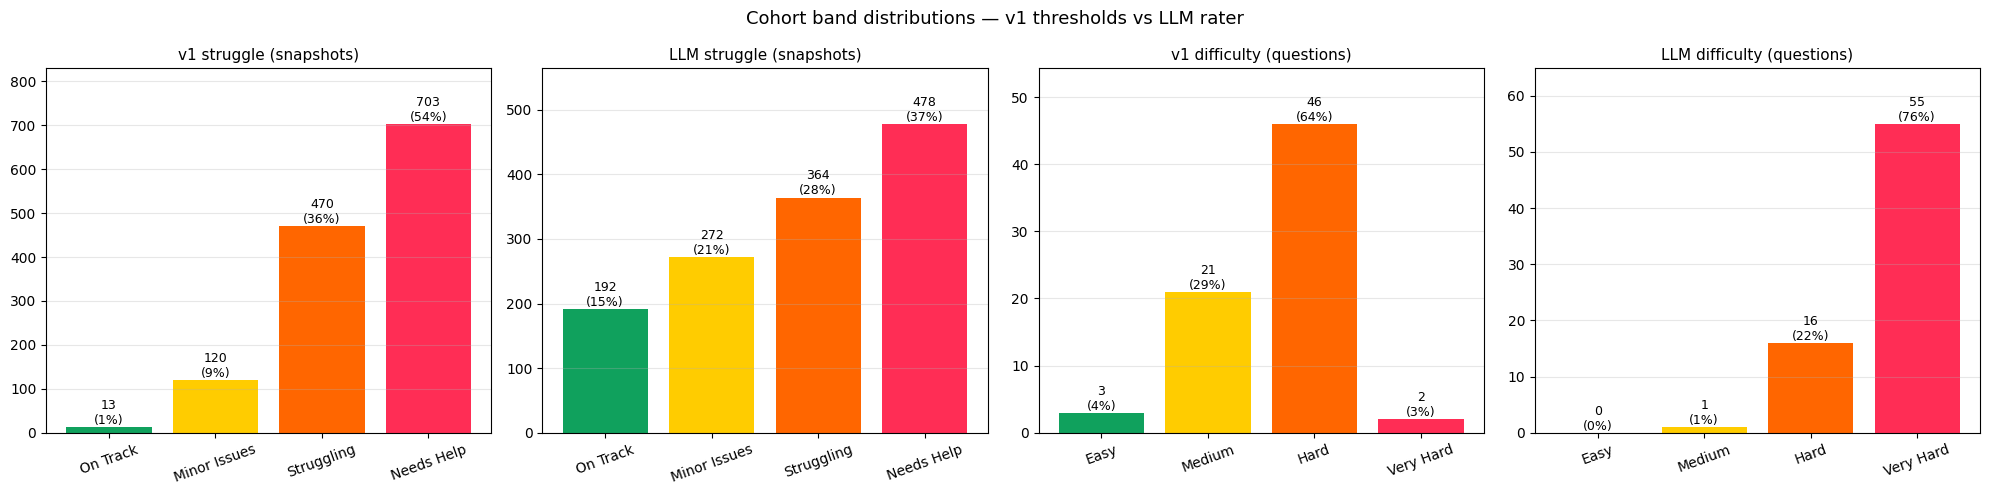

In [4]:
v1_struggle_bands = Counter(s['v1_struggle_level'] for s in snapshots)
v1_difficulty_bands = Counter(q['v1_difficulty_level'] for q in diff_questions)
llm_struggle_bands = Counter(l['band'] for l in llm_struggle_labels.values())
llm_difficulty_bands = Counter(l['band'] for l in llm_difficulty_labels.values())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, counts, bands, total) in zip(axes, [
    ('v1 struggle (snapshots)',    v1_struggle_bands,    STRUGGLE_BANDS,   len(snapshots)),
    ('LLM struggle (snapshots)',   llm_struggle_bands,   STRUGGLE_BANDS,   len(llm_struggle_labels)),
    ('v1 difficulty (questions)',  v1_difficulty_bands,  DIFFICULTY_BANDS, len(diff_questions)),
    ('LLM difficulty (questions)', llm_difficulty_bands, DIFFICULTY_BANDS, len(llm_difficulty_labels)),
]):
    values = [counts.get(b, 0) for b in bands]
    bars = ax.bar(bands, values, color=[COLOR_OK, '#ffcc00', '#ff6600', COLOR_WARN])
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.01,
                f'{v}\n({v/total:.0%})' if total else '0', ha='center', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, max(values) * 1.18 if max(values) else 1)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Cohort band distributions — v1 thresholds vs LLM rater', fontsize=13)
_save('cohort_distributions')
plt.show()

## §5.4.2 — Inter-rater agreement (Cohen's κ)

Human (author) self-labelled 50 random snapshots; compared to GPT-4o-mini ratings on the same 50. κ is poor by Landis-Koch but the within-1-band agreement is 70% — raters agree on direction, disagree on the precise band boundary.

  saved data\eval\figures\kappa.png


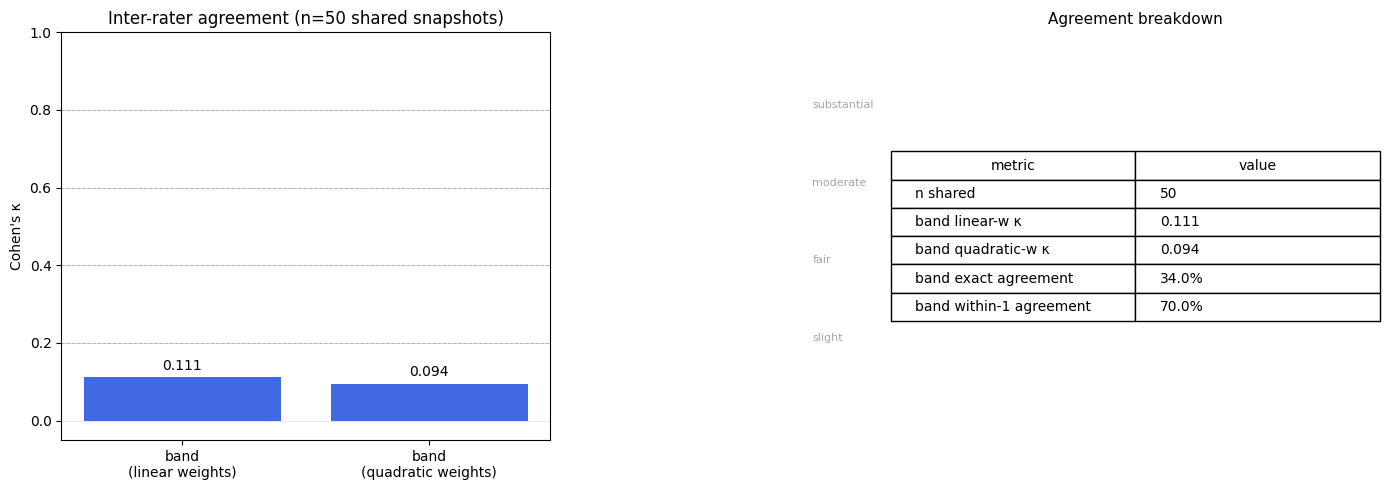

In [5]:
if kappa_report:
    k_band_lin  = kappa_report['kappa_band_linear_weighted']
    k_band_quad = kappa_report['kappa_band_quadratic_weighted']
    n_shared    = kappa_report['n_shared']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    labels = ['band\n(linear weights)', 'band\n(quadratic weights)']
    vals   = [k_band_lin, k_band_quad]
    bars   = ax1.bar(labels, vals, color=[COLOR_V1, COLOR_V1, COLOR_V1])
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
    for y, label in [(0.20, 'slight'), (0.40, 'fair'), (0.60, 'moderate'), (0.80, 'substantial')]:
        ax1.axhline(y, color='grey', linestyle='--', alpha=0.5, linewidth=0.7)
        ax1.text(2.55, y+0.005, label, fontsize=8, color='grey', alpha=0.7)
    ax1.set_ylim(-0.05, 1.0)
    ax1.set_ylabel("Cohen's κ")
    ax1.set_title(f"Inter-rater agreement (n={n_shared} shared snapshots)")
    ax1.grid(True, alpha=0.3, axis='y')

    ax2.axis('off')
    summary = [
        ['n shared',            f"{n_shared}"],
        ['band linear-w κ',     f"{k_band_lin:.3f}"],
        ['band quadratic-w κ',  f"{k_band_quad:.3f}"],
        ['band exact agreement', f"{kappa_report['exact_agreement']['band']['rate']:.1%}"],
        ['band within-1 agreement', f"{kappa_report['within_1_band_agreement']['rate']:.1%}"],
    ]
    tbl = ax2.table(cellText=summary, colLabels=['metric', 'value'], cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)
    ax2.set_title('Agreement breakdown', fontsize=11)

    _save('kappa')
    plt.show()
else:
    print('kappa_report.json missing — skip')

## §5.4.3 — v1 vs v2 weights: STRUGGLE model (HEADLINE)

Paired bars: v1 hand-set weights vs v2 OLS-trained weights. Error bars on v2 from per-fold std (5 folds, session-grouped GroupKFold). Target: 4-band rating (`On Track` ... `Needs Help`). Sign-flipped signals indicate where the trained model disagrees with the hand-set direction — these survive the target swap from binary intervene to the 4-band rating.


  saved data\eval\figures\weights_struggle_v1_vs_v2.png


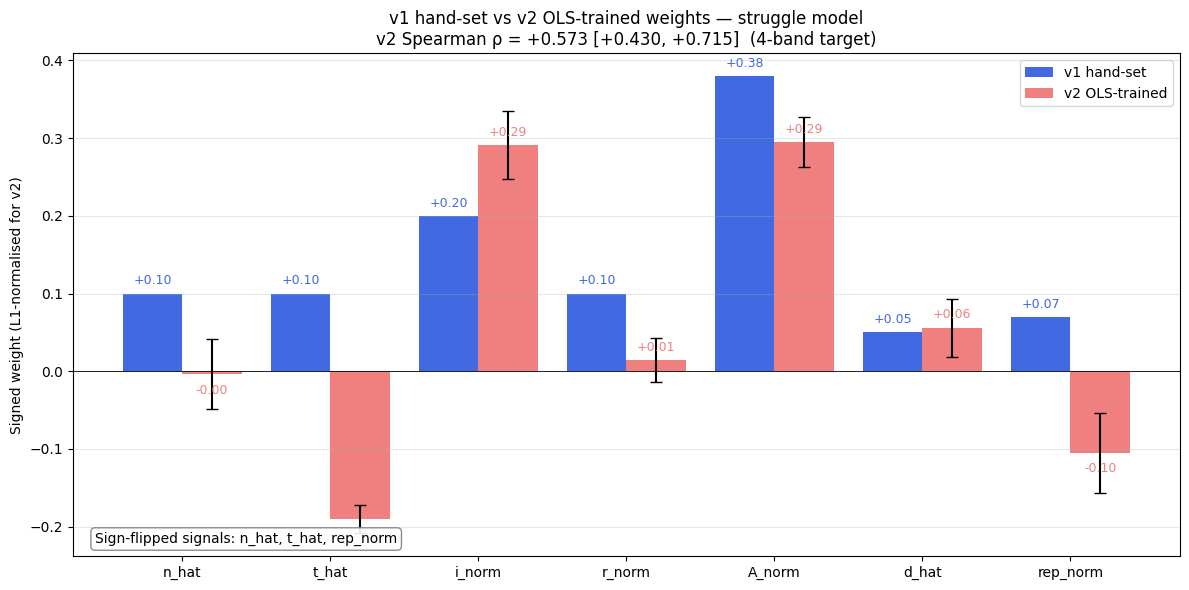

In [6]:
v1_vals = np.array([V1_STRUGGLE_WEIGHTS[s] for s in STRUGGLE_SIGNALS])
v2_vals = np.array([opt_struggle['weights'][s] for s in STRUGGLE_SIGNALS])
v2_std  = np.array([opt_struggle['weights_per_fold_std'][s] for s in STRUGGLE_SIGNALS])

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(STRUGGLE_SIGNALS))
w = 0.4
bars_v1 = ax.bar(x - w/2, v1_vals, w, label='v1 hand-set', color=COLOR_V1)
bars_v2 = ax.bar(x + w/2, v2_vals, w, yerr=v2_std, capsize=4, label='v2 OLS-trained', color=COLOR_V2)
ax.axhline(0, color='black', linewidth=0.6)
for bar, val in zip(bars_v1, v1_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.012 if val >= 0 else val - 0.025,
            f'{val:+.2f}', ha='center', fontsize=9, color=COLOR_V1)
for bar, val in zip(bars_v2, v2_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.012 if val >= 0 else val - 0.025,
            f'{val:+.2f}', ha='center', fontsize=9, color=COLOR_V2)
ax.set_xticks(x)
ax.set_xticklabels(STRUGGLE_SIGNALS)
ax.set_ylabel('Signed weight (L1-normalised for v2)')
rho_mean = opt_struggle['spearman_rho_mean']
rho_lo, rho_hi = opt_struggle['spearman_rho_ci95']
ax.set_title(f"v1 hand-set vs v2 OLS-trained weights — struggle model\n"
             f"v2 Spearman ρ = {rho_mean:+.3f} [{rho_lo:+.3f}, {rho_hi:+.3f}]  (4-band target)")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

flipped = [s for s, v1, v2 in zip(STRUGGLE_SIGNALS, v1_vals, v2_vals) if np.sign(v1) != np.sign(v2)]
flip_text = 'Sign-flipped signals: ' + ', '.join(flipped) if flipped else 'No sign flips'
ax.text(0.02, 0.02, flip_text, transform=ax.transAxes, va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))

_save('weights_struggle_v1_vs_v2')
plt.show()


## §5.4.4 — Per-fold Spearman ρ stability (struggle)

Five-fold session-grouped CV. Stability check: per-fold ρ std should be small relative to mean — confirms the v2 weights generalise across held-out sessions rather than overfitting to one cohort. The CI is reported on the rank correlation; weighted κ + MAE are also computed per fold and summarised below.


  saved data\eval\figures\per_fold_rho_struggle.png


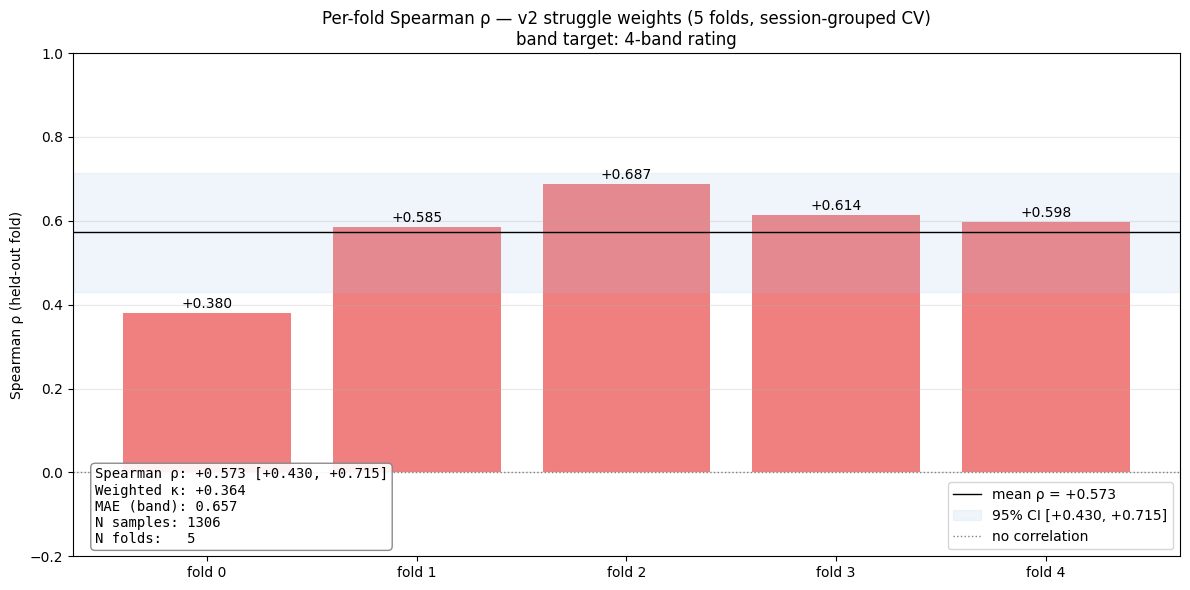

In [7]:
fold_rhos = [f['spearman_rho'] for f in opt_struggle['per_fold']]
mean_rho  = opt_struggle['spearman_rho_mean']
ci_lo, ci_hi = opt_struggle['spearman_rho_ci95']

fig, ax = plt.subplots(figsize=(12, 6))
folds = [f"fold {i}" for i in range(len(fold_rhos))]
bars = ax.bar(folds, fold_rhos, color=COLOR_V2)
for bar, val in zip(bars, fold_rhos):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.012, f'{val:+.3f}', ha='center', fontsize=10)
ax.axhline(mean_rho, color='black', linestyle='-', linewidth=1, label=f'mean ρ = {mean_rho:+.3f}')
ax.axhspan(ci_lo, ci_hi, alpha=0.15, color=COLOR_BAND, label=f'95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]')
ax.axhline(0, color='grey', linestyle=':', linewidth=1, label='no correlation')
ax.set_ylim(-0.2, 1.0)
ax.set_ylabel('Spearman ρ (held-out fold)')
ax.set_title('Per-fold Spearman ρ — v2 struggle weights (5 folds, session-grouped CV)\nband target: 4-band rating')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

kappa_mean = opt_struggle['weighted_kappa_mean']
mae_mean = opt_struggle['mae_mean']
summary_text = (
    f"Spearman ρ: {mean_rho:+.3f} [{ci_lo:+.3f}, {ci_hi:+.3f}]\n"
    f"Weighted κ: {kappa_mean:+.3f}\n"
    f"MAE (band): {mae_mean:.3f}\n"
    f"N samples: {opt_struggle['n_samples']}\n"
    f"N folds:   {opt_struggle['n_folds']}"
)
ax.text(0.02, 0.02, summary_text, transform=ax.transAxes, va='bottom', fontsize=10,
        family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))

_save('per_fold_rho_struggle')
plt.show()


## Re-derivation infrastructure (for ROC / calibration / confusion matrices)

The optimised JSONs store per-fold weights but not per-snapshot predictions. The next few plots need predictions, so we re-fit LR per fold using the same `best_C` and pool the held-out predictions. Predictions get cached to `data/eval/pooled_predictions_v2.json` so re-running cells doesn't re-fit.

In [8]:
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

def rederive_struggle_v2() -> dict:
    """Re-fit OLS per fold against the 4-band target and pool predictions."""
    matched = [s for s in snapshots if s['snapshot_id'] in llm_struggle_labels]
    X = np.array([[s['v1_features'][k] for k in STRUGGLE_SIGNALS] for s in matched])
    y = np.array([STRUGGLE_BAND_INDEX[llm_struggle_labels[s['snapshot_id']]['band']] for s in matched])
    groups = np.array([s['session_id'] for s in matched])
    pooled = np.zeros(len(matched))
    gkf = GroupKFold(n_splits=5)
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        sc = StandardScaler().fit(X[tr])
        ols = LinearRegression()
        ols.fit(sc.transform(X[tr]), y[tr].astype(float))
        pooled[te] = ols.predict(sc.transform(X[te]))
    return {'matched': matched, 'X': X, 'y': y, 'groups': groups, 'pred': pooled}

def v1_struggle_pooled() -> dict:
    """v1 baseline: read the pre-computed live v1_struggle_score from each snapshot."""
    matched = [s for s in snapshots if s['snapshot_id'] in llm_struggle_labels]
    pred = np.array([s['v1_struggle_score'] for s in matched])
    y    = np.array([STRUGGLE_BAND_INDEX[llm_struggle_labels[s['snapshot_id']]['band']] for s in matched])
    return {'matched': matched, 'pred': pred, 'y': y}

v2_struggle = rederive_struggle_v2()
v1_struggle = v1_struggle_pooled()

v1_rho = float(spearmanr(v1_struggle['pred'], v1_struggle['y']).correlation)
v2_rho = float(spearmanr(v2_struggle['pred'], v2_struggle['y']).correlation)
print(f'v1 baseline Spearman ρ (vs band): {v1_rho:+.3f}')
print(f'v2 trained  Spearman ρ (vs band): {v2_rho:+.3f}   '
      f'(stored mean across folds: {opt_struggle["spearman_rho_mean"]:+.3f})')

# Cache pooled predictions for the cells below
pooled_cache = {
    'v1_struggle': {'pred': v1_struggle['pred'].tolist(), 'y': v1_struggle['y'].tolist()},
    'v2_struggle': {'pred': v2_struggle['pred'].tolist(), 'y': v2_struggle['y'].tolist()},
    'snapshot_ids': [s['snapshot_id'] for s in v2_struggle['matched']],
}
(EVAL_DIR / 'pooled_predictions_v2.json').write_text(json.dumps(pooled_cache, indent=2), encoding='utf-8')
print(f'  cached pooled predictions to data/eval/pooled_predictions_v2.json')


v1 baseline Spearman ρ (vs band): +0.423
v2 trained  Spearman ρ (vs band): +0.566   (stored mean across folds: +0.573)
  cached pooled predictions to data/eval/pooled_predictions_v2.json


## §5.4.x — Linear regression fit visualisation (struggle model)

Diagnostic plot for the v2 ordinary least-squares fit. The x-axis is the **predicted band severity** (continuous OLS output, roughly in [0, 3] after clipping); the y-axis is the **observed LLM-rated band index** (integer in {0, 1, 2, 3} with small vertical jitter so points don't overlap). The fitted regression line (predicted = observed identity, slope 1) is overlaid as a reference for perfect prediction.

This is the textbook OLS diagnostic — what makes it informative is how tightly the cloud of points hugs the diagonal. Tight cloud → low MAE + high Spearman ρ; loose cloud → the model is missing systematic structure.


  saved data\eval\figures\ols_diagnostic_struggle.png


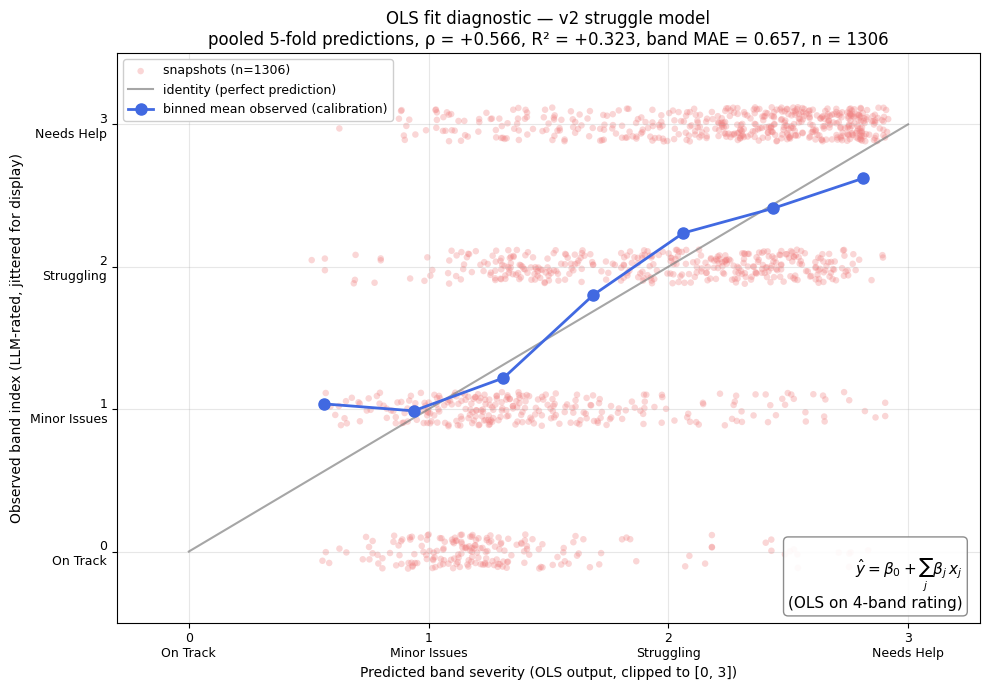

Spearman ρ:       +0.566
R²:               +0.323
MAE (band index): 0.657
Pred range:       [0.51, 2.92]  (clipped to [0, 3] for display)


In [9]:
# OLS diagnostic: predicted band severity vs observed band index, with the
# identity reference line (perfect prediction) overlaid.
from sklearn.metrics import r2_score

pred = v2_struggle['pred']
y    = v2_struggle['y']

# Clip predictions to the valid band range [0, 3] for honest display
pred_clipped = np.clip(pred, 0, N_BANDS - 1)

fig, ax = plt.subplots(figsize=(10, 7))

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.12, 0.12, size=len(y))
ax.scatter(pred_clipped, y + jitter, color=COLOR_V2, alpha=0.32, s=22,
           edgecolor='none', label=f'snapshots (n={len(y)})')

# Identity line (perfect prediction)
ax.plot([0, N_BANDS - 1], [0, N_BANDS - 1], '-', color='grey', linewidth=1.5,
        alpha=0.7, label='identity (perfect prediction)')

# Bin-mean of observed-vs-predicted (calibration of the regression)
bin_edges = np.linspace(0, N_BANDS - 1, 9)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (pred_clipped >= lo) & (pred_clipped < hi)
    bin_means.append(float(np.mean(y[mask])) if mask.any() else np.nan)
ax.plot(bin_centers, bin_means, 'o-', color=COLOR_V1, linewidth=2.0, markersize=8,
        label='binned mean observed (calibration)')

rho = float(spearmanr(pred, y).correlation)
r2  = float(r2_score(y, pred))
mae = float(np.mean(np.abs(np.clip(np.rint(pred), 0, N_BANDS - 1) - y)))

ax.set_xticks(range(N_BANDS))
ax.set_yticks(range(N_BANDS))
ax.set_xticklabels([f'{i}\n{b}' for i, b in enumerate(STRUGGLE_BANDS)], fontsize=9)
ax.set_yticklabels([f'{i}\n{b}' for i, b in enumerate(STRUGGLE_BANDS)], fontsize=9)
ax.set_xlabel('Predicted band severity (OLS output, clipped to [0, 3])')
ax.set_ylabel('Observed band index (LLM-rated, jittered for display)')
ax.set_title(f'OLS fit diagnostic — v2 struggle model\n'
             f'pooled 5-fold predictions, ρ = {rho:+.3f}, R² = {r2:+.3f}, band MAE = {mae:.3f}, n = {len(y)}')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.3, N_BANDS - 0.7)
ax.set_ylim(-0.5, N_BANDS - 0.5)

ax.text(0.98, 0.02,
        r'$\hat{y} = \beta_0 + \sum_j \beta_j\, x_j$' '\n(OLS on 4-band rating)',
        transform=ax.transAxes, fontsize=11, va='bottom', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))

_save('ols_diagnostic_struggle')
plt.show()

print(f'Spearman ρ:       {rho:+.3f}')
print(f'R²:               {r2:+.3f}')
print(f'MAE (band index): {mae:.3f}')
print(f'Pred range:       [{pred.min():.2f}, {pred.max():.2f}]  (clipped to [0, 3] for display)')


## §5.4.x — Predicted-vs-observed band scatter (v1 vs v2 side-by-side)

ROC analysis doesn't apply for a continuous-target regression model. The equivalent diagnostic for the v1-vs-v2 comparison is the **predicted band scatter** — same axes as the OLS diagnostic above, but with v1 (pre-computed live struggle score, rescaled to [0, 3]) and v2 (OLS-trained) shown side by side so the reader can visually compare how tightly each clusters around the diagonal.


  saved data\eval\figures\pred_vs_obs_v1_v2_struggle.png


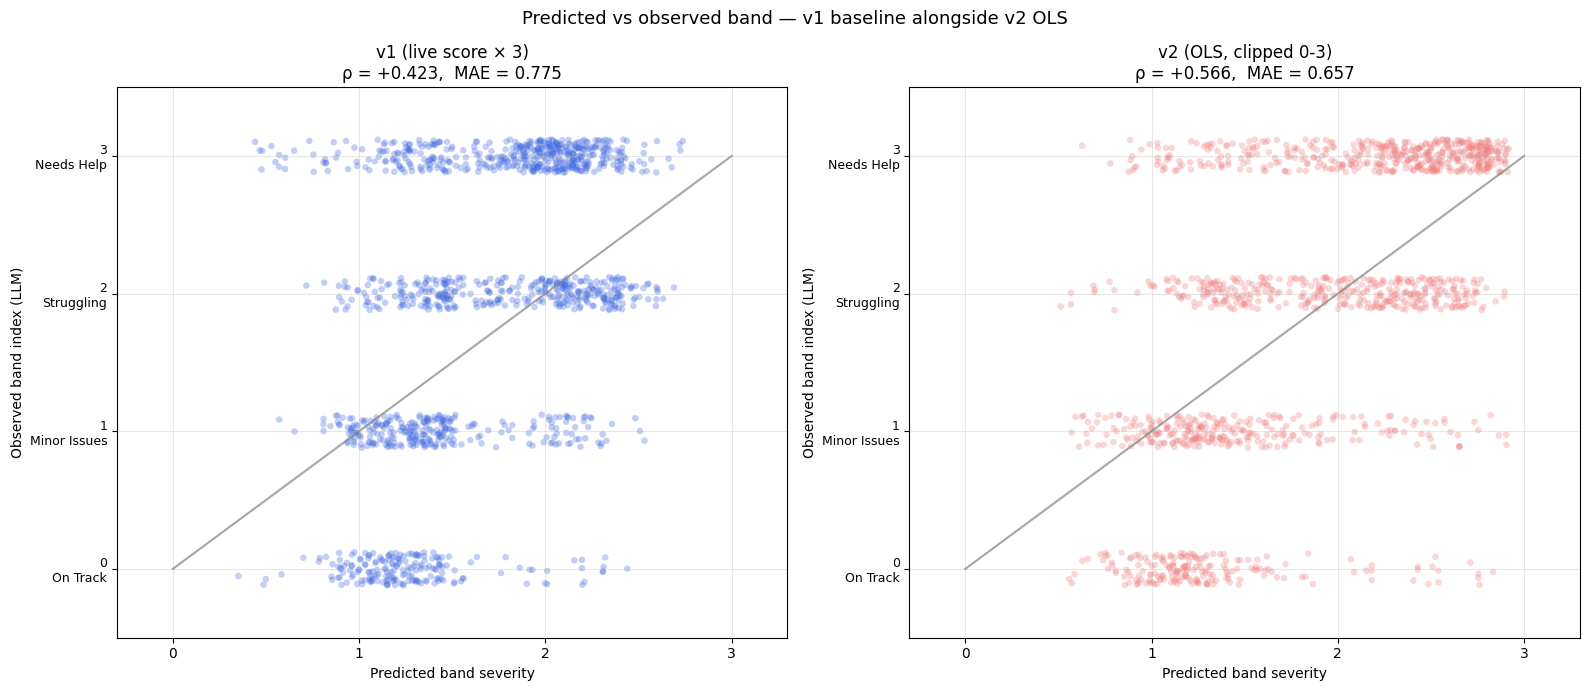

In [10]:
# Predicted-vs-observed band scatter for v1 vs v2 side-by-side.
# Replaces the binary-classification ROC overlay (not applicable for OLS).

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rng = np.random.default_rng(42)

# v1 pre-computed live score is in [0, 1]; rescale to [0, 3] for display alongside v2
v1_pred_scaled = np.array(v1_struggle['pred']) * (N_BANDS - 1)
v2_pred_clipped = np.clip(v2_struggle['pred'], 0, N_BANDS - 1)
y_arr = np.array(v2_struggle['y'])

for ax, pred, label, color in [
    (axes[0], v1_pred_scaled,  'v1 (live score × 3)',  COLOR_V1),
    (axes[1], v2_pred_clipped, 'v2 (OLS, clipped 0-3)', COLOR_V2),
]:
    jitter = rng.uniform(-0.12, 0.12, size=len(y_arr))
    ax.scatter(pred, y_arr + jitter, color=color, alpha=0.32, s=22, edgecolor='none')
    ax.plot([0, N_BANDS - 1], [0, N_BANDS - 1], '-', color='grey', linewidth=1.5, alpha=0.7)
    rho = float(spearmanr(pred, y_arr).correlation)
    mae = float(np.mean(np.abs(np.clip(np.rint(pred), 0, N_BANDS - 1) - y_arr)))
    ax.set_title(f'{label}\nρ = {rho:+.3f},  MAE = {mae:.3f}')
    ax.set_xticks(range(N_BANDS))
    ax.set_yticks(range(N_BANDS))
    ax.set_xticklabels([f'{i}' for i in range(N_BANDS)])
    ax.set_yticklabels([f'{i}\n{b}' for i, b in enumerate(STRUGGLE_BANDS)], fontsize=9)
    ax.set_xlabel('Predicted band severity')
    ax.set_ylabel('Observed band index (LLM)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.3, N_BANDS - 0.7)
    ax.set_ylim(-0.5, N_BANDS - 0.5)

fig.suptitle('Predicted vs observed band — v1 baseline alongside v2 OLS', fontsize=13)
_save('pred_vs_obs_v1_v2_struggle')
plt.show()


## §5.4.x — Residuals diagnostic (OLS)

Binary calibration doesn't apply for a continuous regression. The OLS equivalent is the **residuals-vs-predicted scatter** — for each snapshot, residual = observed band − predicted band. The horizontal trend tells us whether the model systematically over- or under-predicts in different parts of the band range. Random scatter around zero is good; visible trend or fan shape indicates structure the model is missing.


  saved data\eval\figures\residuals_struggle.png


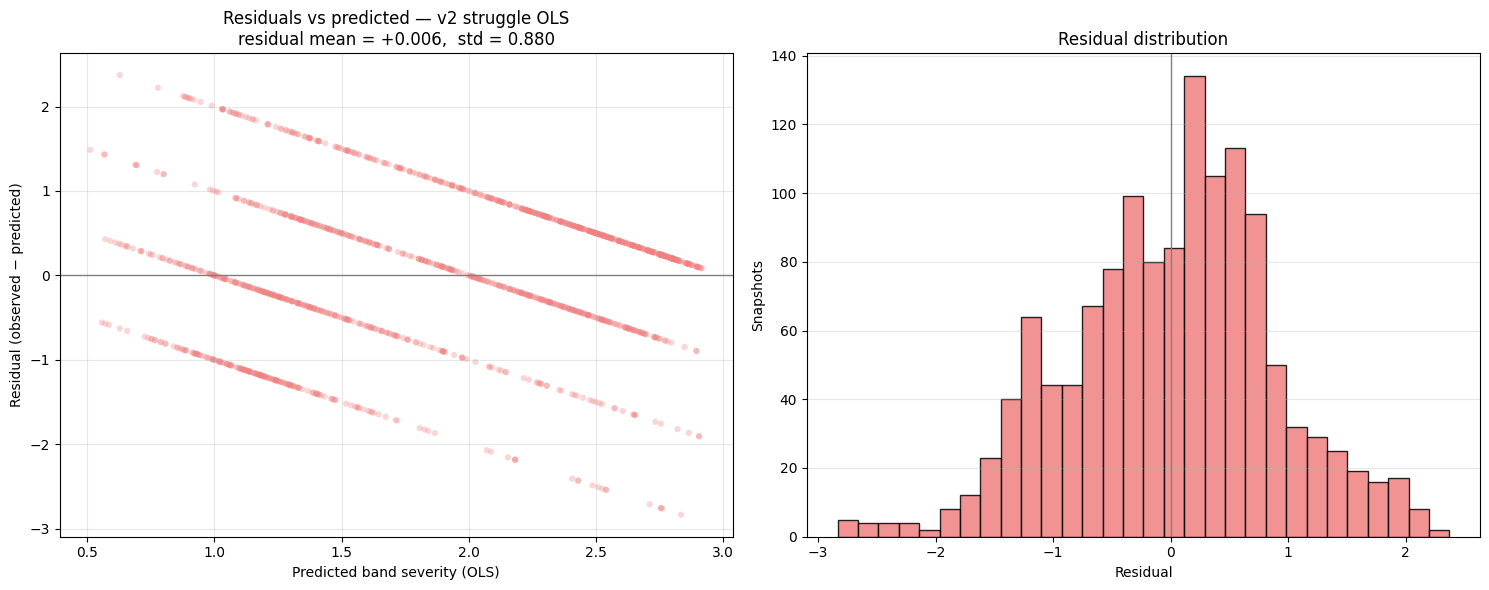

Residual mean: +0.006  (close to 0 = unbiased on average)
Residual std:  0.880
|residual| > 1 band: 336/1306 (25.7%)


In [11]:
# OLS residuals-vs-predicted diagnostic. Replaces the binary calibration plot.

pred = v2_struggle['pred']
y    = v2_struggle['y']
resid = y - pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs predicted
ax1.scatter(pred, resid, color=COLOR_V2, alpha=0.32, s=20, edgecolor='none')
ax1.axhline(0, color='grey', linestyle='-', linewidth=1)
ax1.set_xlabel('Predicted band severity (OLS)')
ax1.set_ylabel('Residual (observed − predicted)')
ax1.set_title(f'Residuals vs predicted — v2 struggle OLS\nresidual mean = {resid.mean():+.3f},  std = {resid.std():.3f}')
ax1.grid(True, alpha=0.3)

# Residual distribution
ax2.hist(resid, bins=30, color=COLOR_V2, edgecolor='black', alpha=0.85)
ax2.axvline(0, color='grey', linestyle='-', linewidth=1)
ax2.set_xlabel('Residual')
ax2.set_ylabel('Snapshots')
ax2.set_title('Residual distribution')
ax2.grid(True, alpha=0.3, axis='y')

_save('residuals_struggle')
plt.show()

print(f'Residual mean: {resid.mean():+.3f}  (close to 0 = unbiased on average)')
print(f'Residual std:  {resid.std():.3f}')
print(f'|residual| > 1 band: {int(np.sum(np.abs(resid) > 1))}/{len(resid)} ({np.mean(np.abs(resid) > 1):.1%})')


## §5.4.7 — Per-fold weight stability (heatmap)

7 signals × 5 folds. Cell colour = signed weight, annotated. If folds agree on sign and magnitude, the v2 weight vector is reproducible; large disagreements would suggest the LR is fitting noise.

  saved data\eval\figures\weight_heatmap_struggle.png


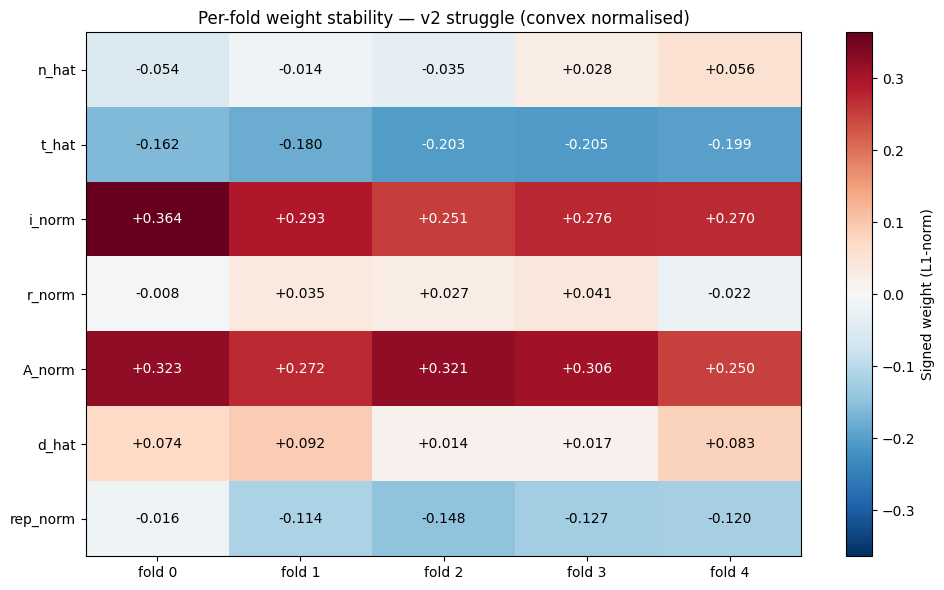

In [12]:
fold_weights = np.array([
    [f['weights_convex'][s] for s in STRUGGLE_SIGNALS]
    for f in opt_struggle['per_fold']
])

fig, ax = plt.subplots(figsize=(10, 6))
vmax = np.abs(fold_weights).max()
im = ax.imshow(fold_weights.T, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(opt_struggle['per_fold'])))
ax.set_xticklabels([f"fold {i}" for i in range(len(opt_struggle['per_fold']))])
ax.set_yticks(range(len(STRUGGLE_SIGNALS)))
ax.set_yticklabels(STRUGGLE_SIGNALS)
for i in range(fold_weights.shape[1]):  # signal
    for j in range(fold_weights.shape[0]):  # fold
        val = fold_weights[j, i]
        color = 'white' if abs(val) > vmax * 0.5 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=10, color=color)
ax.set_title('Per-fold weight stability — v2 struggle (convex normalised)')
fig.colorbar(im, ax=ax, label='Signed weight (L1-norm)')
_save('weight_heatmap_struggle')
plt.show()

## §5.4.8 — Confusion matrix: v1 / v2 predicted bands vs LLM bands

Map pooled predictions to the 4 struggle bands (using `STRUGGLE_THRESHOLDS` from config) and compare to the LLM-rated band on the same snapshot. Quantifies where v1 / v2 over- or under-classify struggle severity vs. the second-opinion rater.

  saved data\eval\figures\confusion_bands.png


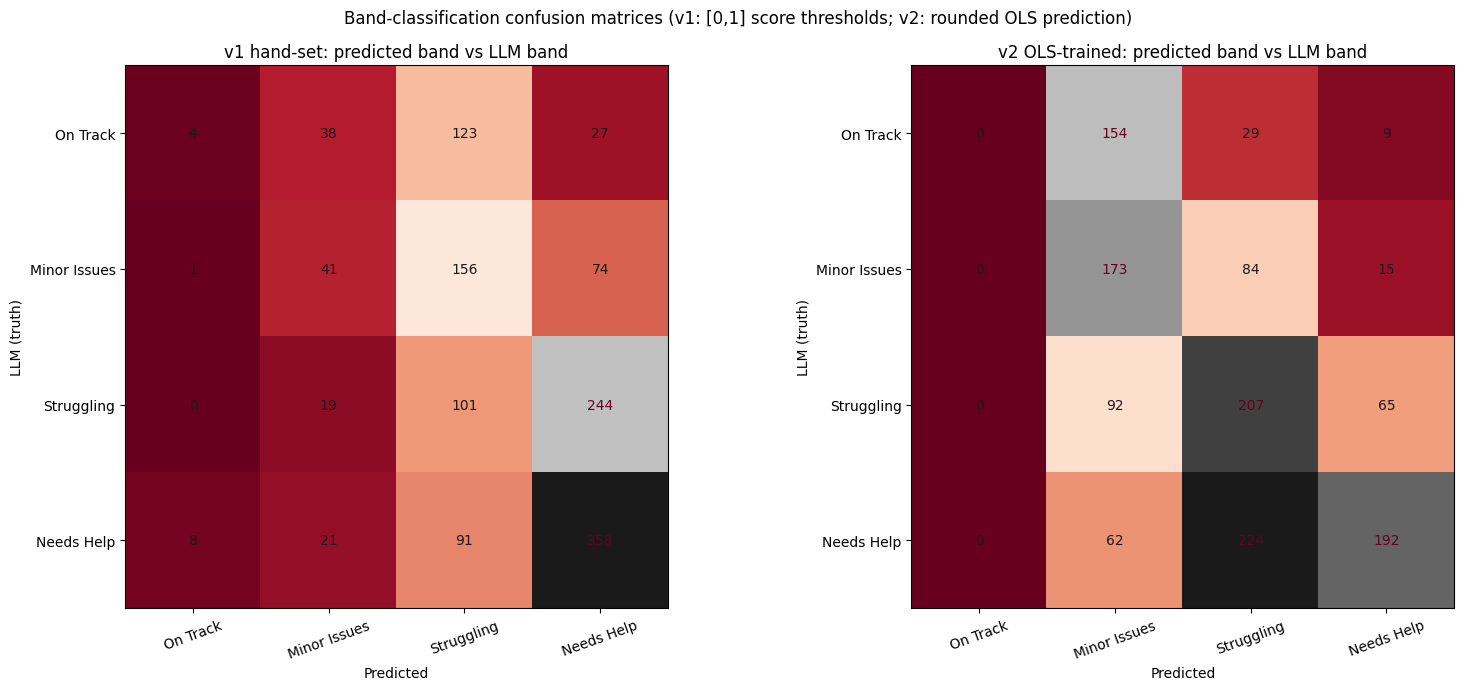

v1 exact-band agreement with LLM: 504/1306 (38.6%)
v2 exact-band agreement with LLM: 572/1306 (43.8%)


In [13]:
STRUGGLE_THRESHOLDS = _bk_config.STRUGGLE_THRESHOLDS

def score_to_band(score: float) -> str:
    """Map a [0, 1] dashboard score to the deployed band via STRUGGLE_THRESHOLDS."""
    for low, high, label, _ in STRUGGLE_THRESHOLDS:
        if low <= score < high:
            return label
    return STRUGGLE_THRESHOLDS[-1][2]

def ols_pred_to_band(pred: float) -> str:
    """Map a continuous OLS prediction (in [0, 3] band-index space) to the band."""
    idx = int(np.clip(np.round(pred), 0, N_BANDS - 1))
    return STRUGGLE_BANDS[idx]

matched = v2_struggle['matched']
llm_bands_arr = np.array([llm_struggle_labels[s['snapshot_id']]['band'] for s in matched])

# v1 uses the deployed [0, 1] dashboard score → STRUGGLE_THRESHOLDS mapping
v1_bands_arr = np.array([score_to_band(p) for p in v1_struggle['pred']])
# v2 OLS output is in band-index space [0, 3] — round + clip + look up
v2_bands_arr = np.array([ols_pred_to_band(p) for p in v2_struggle['pred']])

cm_v1 = confusion_matrix(llm_bands_arr, v1_bands_arr, labels=STRUGGLE_BANDS)
cm_v2 = confusion_matrix(llm_bands_arr, v2_bands_arr, labels=STRUGGLE_BANDS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, cm, title in [(ax1, cm_v1, 'v1 hand-set'), (ax2, cm_v2, 'v2 OLS-trained')]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=STRUGGLE_BANDS)
    disp.plot(ax=ax, cmap='RdGy', values_format='d', xticks_rotation=20, colorbar=False)
    ax.set_title(f'{title}: predicted band vs LLM band')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('LLM (truth)')
fig.suptitle('Band-classification confusion matrices (v1: [0,1] score thresholds; v2: rounded OLS prediction)')
_save('confusion_bands')
plt.show()

agree_v1 = int(np.diag(cm_v1).sum())
agree_v2 = int(np.diag(cm_v2).sum())
total = int(cm_v1.sum())
print(f'v1 exact-band agreement with LLM: {agree_v1}/{total} ({agree_v1/total:.1%})')
print(f'v2 exact-band agreement with LLM: {agree_v2}/{total} ({agree_v2/total:.1%})')


## §5.4.9 — Negative findings: difficulty + improved model

Two paired bar charts mirroring §5.4.3 but for the models where v2 *underperforms* v1.

- **Difficulty v2** has a weak positive Spearman ρ but the cohort skews heavily Very Hard (76% of questions), leaving little signal to fit. The negative `t_tilde` and `a_tilde` weights survive the target swap.
- **Improved-struggle v2** assigns negative weight to `w_M` (BKT mastery-gap) and `w_D` (IRT-adjusted exposure) under OLS just as it did under logistic regression — the LR concludes these components add noise rather than signal for band severity prediction.


  saved data\eval\figures\negative_findings.png


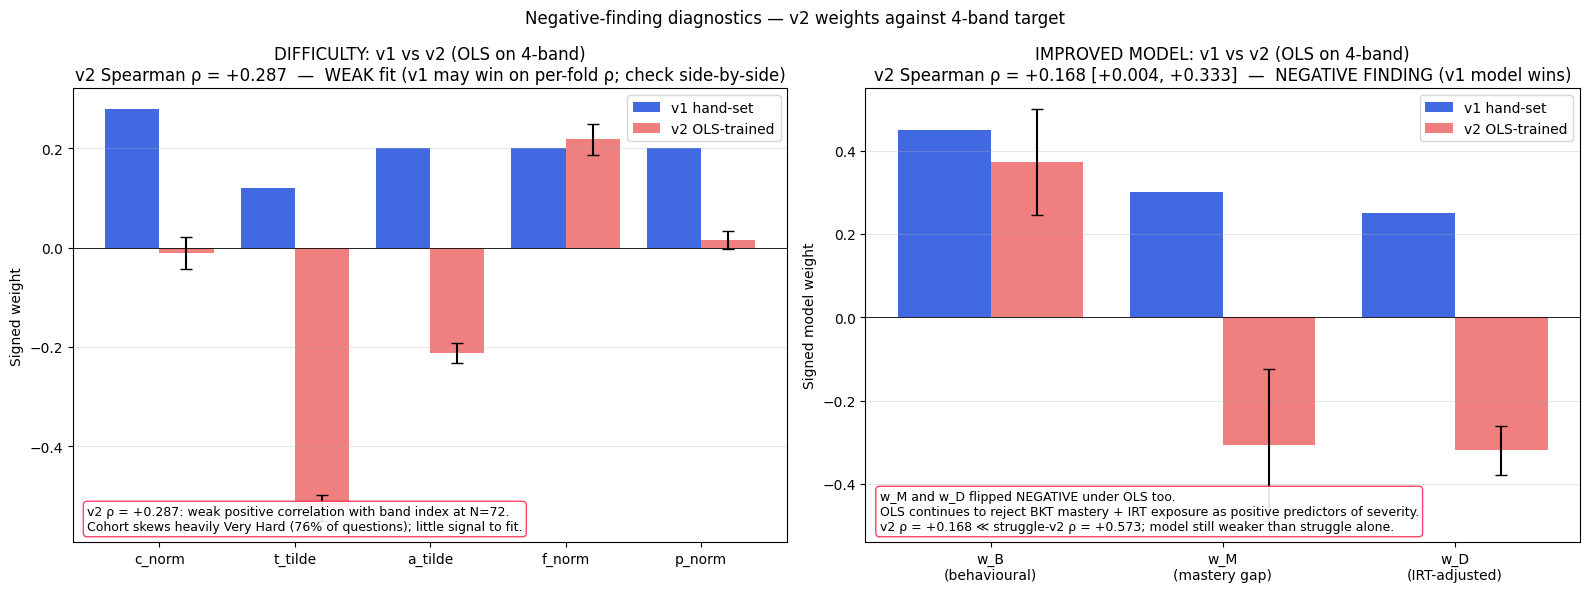

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Difficulty ---
ax = axes[0]
v1d = np.array([V1_DIFFICULTY_WEIGHTS[s] for s in DIFFICULTY_SIGNALS])
v2d = np.array([opt_difficulty['weights'][s] for s in DIFFICULTY_SIGNALS])
v2d_std = np.array([opt_difficulty['weights_per_fold_std'][s] for s in DIFFICULTY_SIGNALS])
x = np.arange(len(DIFFICULTY_SIGNALS))
w = 0.4
ax.bar(x - w/2, v1d, w, label='v1 hand-set', color=COLOR_V1)
ax.bar(x + w/2, v2d, w, yerr=v2d_std, capsize=4, label='v2 OLS-trained', color=COLOR_V2)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(DIFFICULTY_SIGNALS)
ax.set_ylabel('Signed weight')
diff_rho = opt_difficulty['spearman_rho_mean']
ax.set_title(f"DIFFICULTY: v1 vs v2 (OLS on 4-band)\nv2 Spearman ρ = {diff_rho:+.3f}  —  WEAK fit (v1 may win on per-fold ρ; check side-by-side)")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.text(0.02, 0.02,
        f'v2 ρ = {diff_rho:+.3f}: weak positive correlation with band index at N={opt_difficulty["n_samples"]}.\n'
        'Cohort skews heavily Very Hard (76% of questions); little signal to fit.',
        transform=ax.transAxes, va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=COLOR_WARN))

# --- Improved-struggle ---
ax = axes[1]
IMP_LABELS = ['w_B\n(behavioural)', 'w_M\n(mastery gap)', 'w_D\n(IRT-adjusted)']
v1i = np.array([V1_IMPROVED_WEIGHTS[k] for k in ['w_B', 'w_M', 'w_D']])
v2i = np.array([opt_improved['weights'][k] for k in ['w_B', 'w_M', 'w_D']])
v2i_std = np.array([opt_improved['weights_per_fold_std'][k] for k in ['w_B', 'w_M', 'w_D']])
x = np.arange(3)
ax.bar(x - w/2, v1i, w, label='v1 hand-set', color=COLOR_V1)
ax.bar(x + w/2, v2i, w, yerr=v2i_std, capsize=4, label='v2 OLS-trained', color=COLOR_V2)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(IMP_LABELS)
ax.set_ylabel('Signed model weight')
imp_rho = opt_improved['spearman_rho_mean']
imp_rho_lo, imp_rho_hi = opt_improved['spearman_rho_ci95']
ax.set_title(f"IMPROVED MODEL: v1 vs v2 (OLS on 4-band)\nv2 Spearman ρ = {imp_rho:+.3f} [{imp_rho_lo:+.3f}, {imp_rho_hi:+.3f}]  —  NEGATIVE FINDING (v1 model wins)")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.text(0.02, 0.02,
        f'w_M and w_D flipped NEGATIVE under OLS too.\n'
        f'OLS continues to reject BKT mastery + IRT exposure as positive predictors of severity.\n'
        f'v2 ρ = {imp_rho:+.3f} ≪ struggle-v2 ρ = {opt_struggle["spearman_rho_mean"]:+.3f}; model still weaker than struggle alone.',
        transform=ax.transAxes, va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=COLOR_WARN))

fig.suptitle('Negative-finding diagnostics — v2 weights against 4-band target', fontsize=12)
_save('negative_findings')
plt.show()


## §5.6.1 — Model disagreement matrix (v1 ↔ v2 bands on shared snapshots)

Predicted struggle bands under v1 vs under v2 for the same 1306 snapshots. The off-diagonals show where v2 reclassifies students; the diagonal shows agreement. Headline number: percentage of snapshots whose band changes under v2.

  saved data\eval\figures\model_disagreement.png


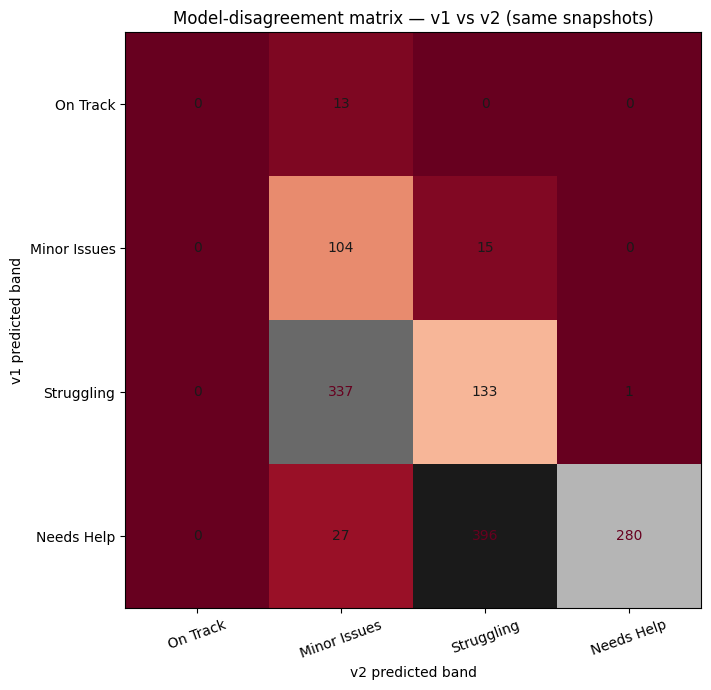

Same band under v1 and v2: 517/1306 (39.6%)
Reclassified under v2:     789/1306 (60.4%)
Upgraded (v2 sees as more severe):   29 (2.2%)
Downgraded (v2 sees as less severe): 760 (58.2%)


In [15]:
cm_v1v2 = confusion_matrix(v1_bands_arr, v2_bands_arr, labels=STRUGGLE_BANDS)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_v1v2, display_labels=STRUGGLE_BANDS)
disp.plot(ax=ax, cmap='RdGy', values_format='d', xticks_rotation=20, colorbar=False)
ax.set_xlabel('v2 predicted band')
ax.set_ylabel('v1 predicted band')
ax.set_title('Model-disagreement matrix — v1 vs v2 (same snapshots)')
_save('model_disagreement')
plt.show()

n_same = int(np.diag(cm_v1v2).sum())
n_total = int(cm_v1v2.sum())
n_diff = n_total - n_same
print(f'Same band under v1 and v2: {n_same}/{n_total} ({n_same/n_total:.1%})')
print(f'Reclassified under v2:     {n_diff}/{n_total} ({n_diff/n_total:.1%})')

upgrades = 0
downgrades = 0
for i, vi_band in enumerate(STRUGGLE_BANDS):
    for j, vj_band in enumerate(STRUGGLE_BANDS):
        if i == j: continue
        # Higher index = more severe band; v2 j>i means v2 sees it as worse
        if j > i:
            upgrades += cm_v1v2[i, j]
        else:
            downgrades += cm_v1v2[i, j]
print(f'Upgraded (v2 sees as more severe):   {upgrades} ({upgrades/n_total:.1%})')
print(f'Downgraded (v2 sees as less severe): {downgrades} ({downgrades/n_total:.1%})')

## §5.4.10 — Hyperparam optimisation (Optuna TPE, Spearman ρ objective)

Two parallel TPE studies, 50 trials each, session-grouped 5-fold CV against the 4-band target. Joint plot of trajectories (trial number vs ρ) and optimisation landscape (parameter value vs ρ).

**Headline**:
- **Shrinkage K**: best=1, ρ≈0.444, Δ≈+0.013 vs v1 K=5 → tied within noise (hand-set near-optimal)
- **CF τ**: best=0.899, ρ≈0.434, Δ≈+0.200 vs v1 τ=0.7 → substantial positive (hand-set τ was too permissive)

**Caveat**: best τ landed at the upper boundary of the [0.4, 0.9] search range — finer search may yield further improvement.


  saved data\eval\figures\hyperparams_optuna.png


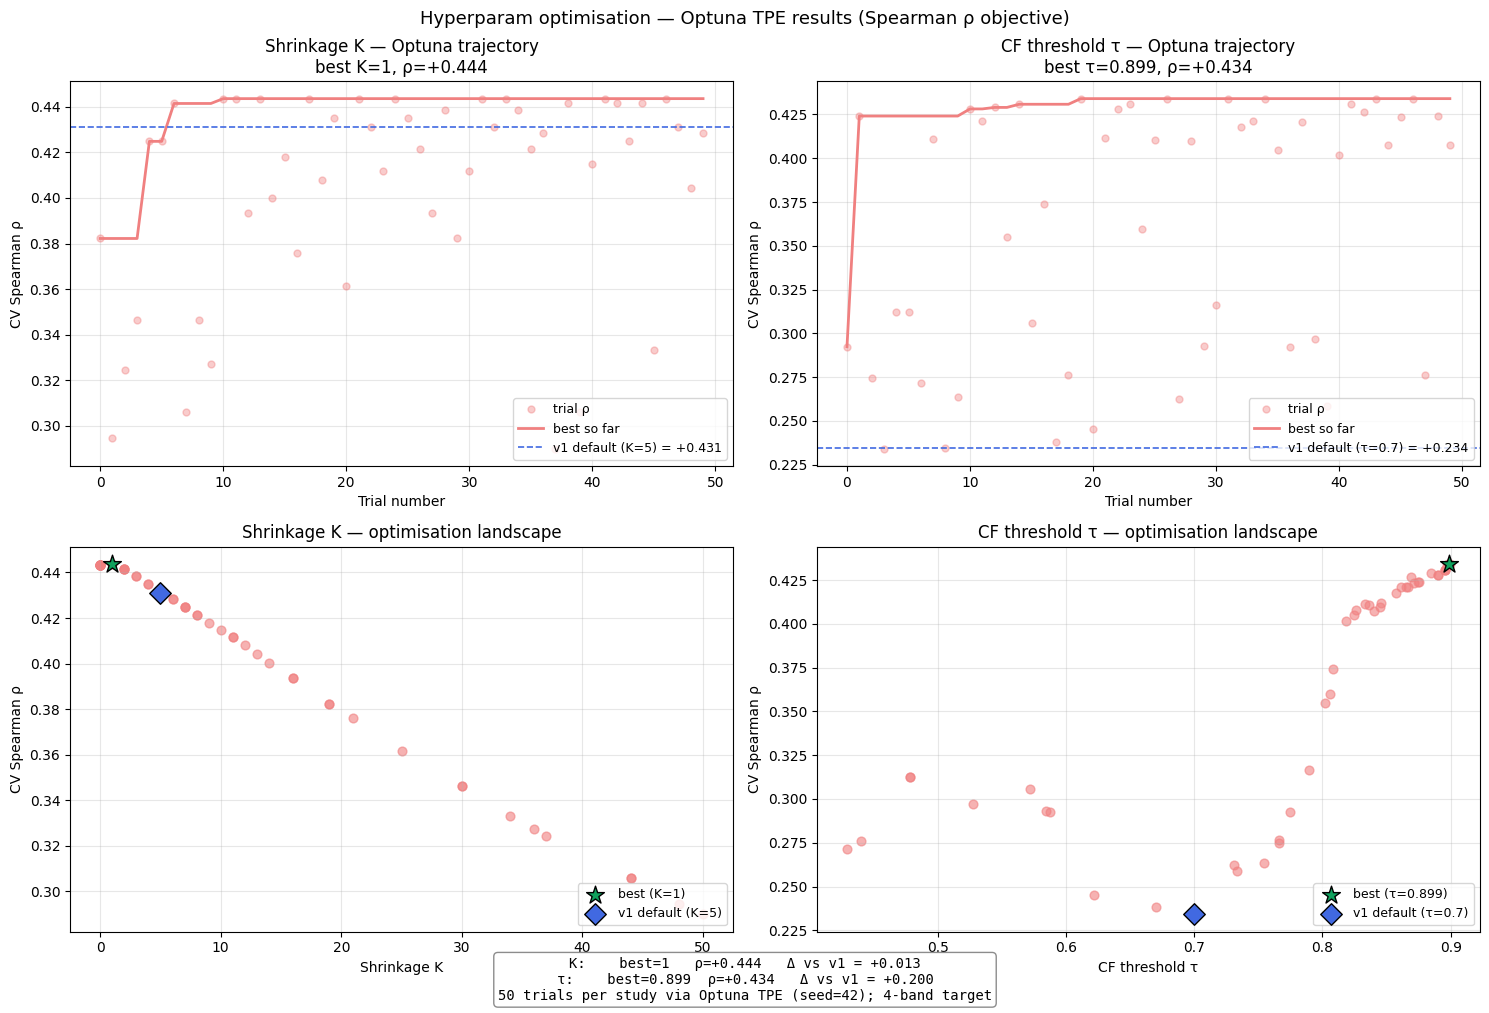

In [16]:
opt_hp = _load('optimised_hyperparams_v2.json')
if opt_hp is None:
    print('optimised_hyperparams_v2.json missing — run scripts/optimise_hyperparams.py first')
else:
    # Extract per-trial data for both studies
    k_trials = opt_hp['studies']['shrinkage_k']['trials']
    t_trials = opt_hp['studies']['cf_threshold']['trials']
    k_x = [t['number'] for t in k_trials]
    k_y = [t['value'] for t in k_trials]
    k_param = [t['params']['shrinkage_k'] for t in k_trials]
    t_x = [t['number'] for t in t_trials]
    t_y = [t['value'] for t in t_trials]
    t_param = [t['params']['cf_threshold'] for t in t_trials]

    best_k       = opt_hp['best_values']['shrinkage_k']
    best_t       = opt_hp['best_values']['cf_threshold']
    best_k_rho   = opt_hp['best_rhos']['shrinkage_k_best']
    best_t_rho   = opt_hp['best_rhos']['cf_threshold_best']
    base_k_rho   = opt_hp['v1_baseline_rhos']['shrinkage_k_at_default']
    base_t_rho   = opt_hp['v1_baseline_rhos']['cf_threshold_at_default']
    default_k    = opt_hp['v1_baseline_rhos']['default_k']
    default_tau  = opt_hp['v1_baseline_rhos']['default_tau']

    # Optuna's "best-so-far" running maximum — clearer than raw trial values
    k_best_so_far = np.maximum.accumulate(k_y)
    t_best_so_far = np.maximum.accumulate(t_y)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # --- (0, 0): K trajectory ---
    ax = axes[0, 0]
    ax.plot(k_x, k_y, 'o', color=COLOR_V2, alpha=0.4, markersize=5, label='trial ρ')
    ax.plot(k_x, k_best_so_far, '-', color=COLOR_V2, linewidth=2, label='best so far')
    ax.axhline(base_k_rho, color=COLOR_V1, linestyle='--', linewidth=1.2,
               label=f'v1 default (K={default_k}) = {base_k_rho:+.3f}')
    ax.set_xlabel('Trial number'); ax.set_ylabel('CV Spearman ρ')
    ax.set_title(f'Shrinkage K — Optuna trajectory\nbest K={best_k}, ρ={best_k_rho:+.3f}')
    ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)

    # --- (0, 1): τ trajectory ---
    ax = axes[0, 1]
    ax.plot(t_x, t_y, 'o', color=COLOR_V2, alpha=0.4, markersize=5, label='trial ρ')
    ax.plot(t_x, t_best_so_far, '-', color=COLOR_V2, linewidth=2, label='best so far')
    ax.axhline(base_t_rho, color=COLOR_V1, linestyle='--', linewidth=1.2,
               label=f'v1 default (τ={default_tau}) = {base_t_rho:+.3f}')
    ax.set_xlabel('Trial number'); ax.set_ylabel('CV Spearman ρ')
    ax.set_title(f'CF threshold τ — Optuna trajectory\nbest τ={best_t:.3f}, ρ={best_t_rho:+.3f}')
    ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)

    # --- (1, 0): K vs ρ landscape ---
    ax = axes[1, 0]
    ax.scatter(k_param, k_y, color=COLOR_V2, alpha=0.6, s=40)
    ax.scatter([best_k], [best_k_rho], color=COLOR_OK, s=180, marker='*',
               edgecolor='black', linewidth=1.0, zorder=5, label=f'best (K={best_k})')
    ax.scatter([default_k], [base_k_rho], color=COLOR_V1, s=120, marker='D',
               edgecolor='black', linewidth=1.0, zorder=5, label=f'v1 default (K={default_k})')
    ax.set_xlabel('Shrinkage K'); ax.set_ylabel('CV Spearman ρ')
    ax.set_title('Shrinkage K — optimisation landscape')
    ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)

    # --- (1, 1): τ vs ρ landscape ---
    ax = axes[1, 1]
    ax.scatter(t_param, t_y, color=COLOR_V2, alpha=0.6, s=40)
    ax.scatter([best_t], [best_t_rho], color=COLOR_OK, s=180, marker='*',
               edgecolor='black', linewidth=1.0, zorder=5, label=f'best (τ={best_t:.3f})')
    ax.scatter([default_tau], [base_t_rho], color=COLOR_V1, s=120, marker='D',
               edgecolor='black', linewidth=1.0, zorder=5, label=f'v1 default (τ={default_tau})')
    ax.set_xlabel('CF threshold τ'); ax.set_ylabel('CV Spearman ρ')
    ax.set_title('CF threshold τ — optimisation landscape')
    ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)

    summary = (
        f"K:    best={best_k}   ρ={best_k_rho:+.3f}   Δ vs v1 = {best_k_rho - base_k_rho:+.3f}\n"
        f"τ:    best={best_t:.3f}  ρ={best_t_rho:+.3f}   Δ vs v1 = {best_t_rho - base_t_rho:+.3f}\n"
        f"50 trials per study via Optuna TPE (seed=42); 4-band target"
    )
    fig.suptitle('Hyperparam optimisation — Optuna TPE results (Spearman ρ objective)', fontsize=13)
    fig.text(0.5, -0.01, summary, ha='center', fontsize=10, family='monospace',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))

    _save('hyperparams_optuna')
    plt.show()


## §5.4.10 (extension) — Joint K × τ study for stock Optuna plots

Stock Optuna visualisations (`plot_contour`, `plot_param_importances`) require multiple parameters in a SINGLE study. This section re-runs the optimisation as one joint K × τ study (100 trials) so we can produce:

- `plot_contour(K, τ)` — 2D heatmap of the joint optimisation surface
- `plot_param_importances` — quantifies "τ matters, K doesn't"
- `plot_optimization_history` — best-so-far joint ρ over trial number

Joint objective = mean of the two separate Spearman ρ values (struggle-with-K and CF-with-τ against the 4-band). Symmetric formulation.

⏱ Wall-clock: ~5–10 min for 100 trials. Cached pickle is auto-deleted on first run after the target swap so the joint study uses the new 4-band objective.


In [17]:
# Joint K × τ Optuna study — mirrors scripts/optimise_hyperparams.py logic but
# runs both hyperparameters in ONE multi-param study so plot_contour and
# plot_param_importances work on the result. Now uses Spearman ρ objective.
import optuna
import joblib
from backend import collab

optuna.logging.set_verbosity(optuna.logging.WARNING)

labels_payload_hp = _load('llm_struggle_labels.json') or {}
labels_hp = labels_payload_hp.get('labels', {})

matched_hp = [s for s in snapshots if s['snapshot_id'] in labels_hp]
y_hp       = np.array([STRUGGLE_BAND_INDEX[labels_hp[s['snapshot_id']]['band']] for s in matched_hp])
groups_hp  = np.array([s['session_id'] for s in matched_hp])

cohorts_hp = defaultdict(list)
for idx, s in enumerate(matched_hp):
    cohorts_hp[(s['session_id'], s['t'])].append(idx)

gkf_hp = GroupKFold(n_splits=5)
fold_splits_hp = list(gkf_hp.split(np.zeros(len(matched_hp)), y_hp, groups_hp))

CF_FEATURES_HP = collab.CF_FEATURES

def _raw_struggle_hp(s):
    raw = sum(V1_STRUGGLE_WEIGHTS[k] * s['v1_features'][k] for k in STRUGGLE_SIGNALS)
    return float(np.clip(raw, 0.0, 1.0))

_raws_hp = np.array([_raw_struggle_hp(s) for s in matched_hp])

def _score_with_k(K):
    preds = np.zeros(len(matched_hp))
    for member_indices in cohorts_hp.values():
        cohort_mean = float(_raws_hp[member_indices].mean())
        for idx in member_indices:
            n = matched_hp[idx]['context']['n_submissions_so_far']
            w_n = n / (n + K) if (n + K) > 0 else 0.0
            preds[idx] = float(np.clip(w_n * _raws_hp[idx] + (1 - w_n) * cohort_mean, 0.0, 1.0))
    return preds

def _score_with_tau(tau):
    preds = np.zeros(len(matched_hp))
    for member_indices in cohorts_hp.values():
        rows = []
        for idx in member_indices:
            s = matched_hp[idx]
            row = {'user': s['user'], 'struggle_score': _raws_hp[idx]}
            for col in CF_FEATURES_HP:
                row[col] = s['v1_features'][col]
            rows.append(row)
        cohort_df = pd.DataFrame(rows)
        cf_series, _diag = collab.compute_cf_struggle_scores(cohort_df, threshold=tau, k=3)
        for i, idx in enumerate(member_indices):
            preds[idx] = float(np.clip(cf_series.iloc[i], 0.0, 1.0))
    return preds

def _cv_spearman(preds):
    fold_rhos = []
    for _tr, te in fold_splits_hp:
        if len(np.unique(y_hp[te])) < 2 or len(te) < 2:
            continue
        rho = spearmanr(preds[te], y_hp[te]).correlation
        if rho is None or np.isnan(rho):
            continue
        fold_rhos.append(float(rho))
    return float(np.mean(fold_rhos)) if fold_rhos else float('nan')

def joint_objective(trial):
    K   = trial.suggest_int('shrinkage_k', 0, 50)
    tau = trial.suggest_float('cf_threshold', 0.4, 0.9)
    rho_k   = _cv_spearman(_score_with_k(K))
    rho_tau = _cv_spearman(_score_with_tau(tau))
    trial.set_user_attr('rho_struggle_K', rho_k)
    trial.set_user_attr('rho_cf_tau', rho_tau)
    return 0.5 * (rho_k + rho_tau)

# Force a fresh run if the cached pickle is from the old binary-target study
STUDY_PATH = EVAL_DIR / 'study_joint_k_tau.pkl'
N_TRIALS = 100

# Always force fresh — the old pickle (if present) was trained on the binary intervene target
if STUDY_PATH.exists():
    STUDY_PATH.unlink()
    print(f'Removed stale pickle {STUDY_PATH.relative_to(REPO_ROOT)} (binary-target study)')

print(f'Running joint K × τ study (TPE, {N_TRIALS} trials, ~5-10 min, Spearman ρ objective)...')
study_joint = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='joint_k_tau',
)
study_joint.optimize(joint_objective, n_trials=N_TRIALS, show_progress_bar=True)
joblib.dump(study_joint, STUDY_PATH)
print(f'  → saved {STUDY_PATH.relative_to(REPO_ROOT)}')

bp = study_joint.best_params
bt = study_joint.best_trial
print(f"\nBest joint: K={bp['shrinkage_k']}, τ={bp['cf_threshold']:.3f}")
print(f"  mean ρ                = {study_joint.best_value:+.4f}")
print(f"  struggle ρ at best K  = {bt.user_attrs['rho_struggle_K']:+.4f}")
print(f"  CF ρ at best τ        = {bt.user_attrs['rho_cf_tau']:+.4f}")


Removed stale pickle data\eval\study_joint_k_tau.pkl (binary-target study)
Running joint K × τ study (TPE, 100 trials, ~5-10 min, Spearman ρ objective)...


  0%|          | 0/100 [00:00<?, ?it/s]

  → saved data\eval\study_joint_k_tau.pkl

Best joint: K=1, τ=0.899
  mean ρ                = +0.4388
  struggle ρ at best K  = +0.4436
  CF ρ at best τ        = +0.4340


C:\Users\Bakri\AppData\Local\Temp\ipykernel_7788\1217548520.py:7: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  ax_contour = ov.plot_contour(study_joint, params=['shrinkage_k', 'cf_threshold'])


  saved data\eval\figures\optuna_joint_contour.png


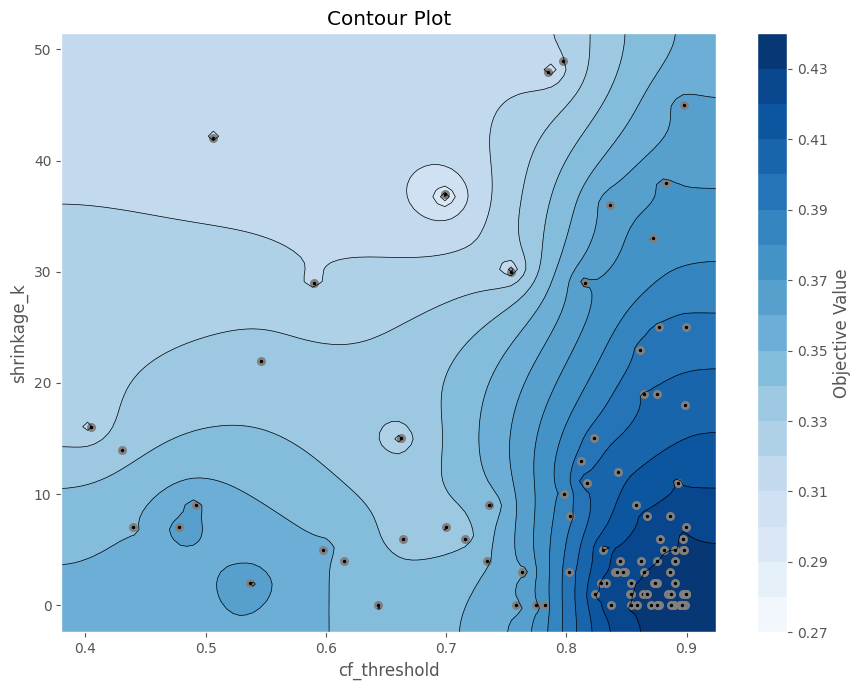

C:\Users\Bakri\AppData\Local\Temp\ipykernel_7788\1217548520.py:16: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax_imp = ov.plot_param_importances(study_joint)


  saved data\eval\figures\optuna_joint_importances.png


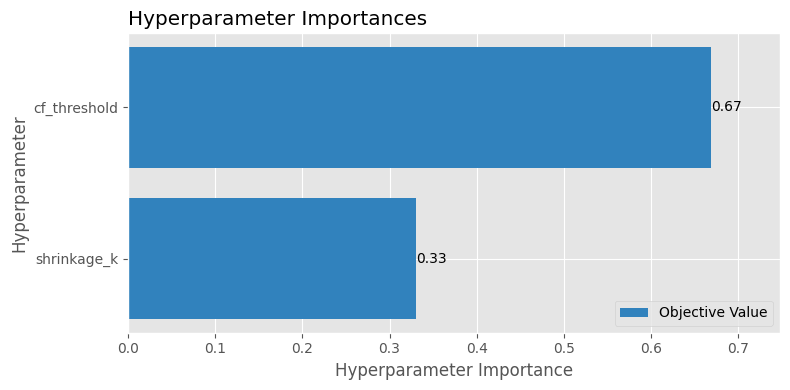

C:\Users\Bakri\AppData\Local\Temp\ipykernel_7788\1217548520.py:25: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax_hist = ov.plot_optimization_history(study_joint)


  saved data\eval\figures\optuna_joint_history.png


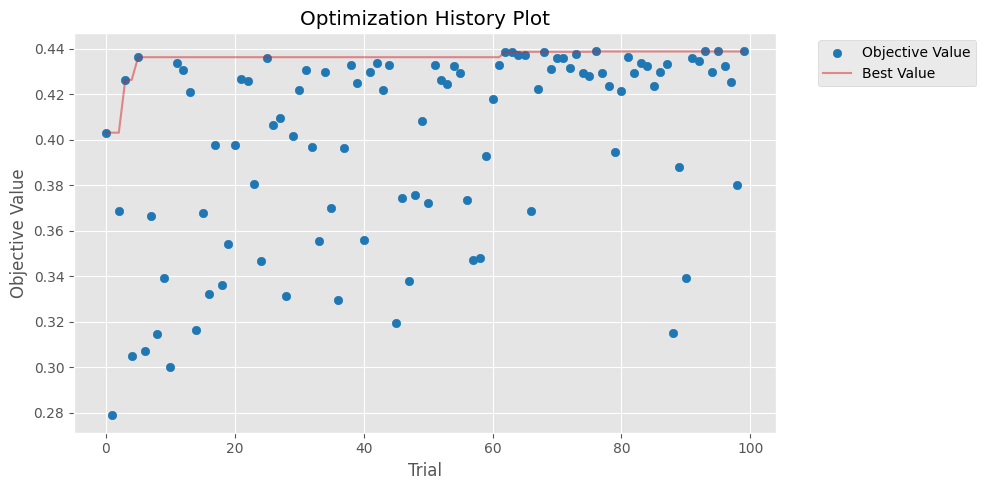

In [18]:
# Stock Optuna plots — contour, param-importances, optimisation history.
# Each call to optuna.visualization.matplotlib.* creates its own figure;
# we grab .figure off the returned Axes and save.
import optuna.visualization.matplotlib as ov

# 1. Contour — joint K × τ surface (headline figure for §5.4.10 extension)
ax_contour = ov.plot_contour(study_joint, params=['shrinkage_k', 'cf_threshold'])
fig_contour = ax_contour.figure if hasattr(ax_contour, 'figure') else plt.gcf()
fig_contour.set_size_inches(9, 7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'optuna_joint_contour.png', dpi=200, bbox_inches='tight')
print(f"  saved {(FIG_DIR / 'optuna_joint_contour.png').relative_to(REPO_ROOT)}")
plt.show()

# 2. Parameter importance — quantifies "τ matters, K doesn't"
ax_imp = ov.plot_param_importances(study_joint)
fig_imp = ax_imp.figure if hasattr(ax_imp, 'figure') else plt.gcf()
fig_imp.set_size_inches(8, 4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'optuna_joint_importances.png', dpi=200, bbox_inches='tight')
print(f"  saved {(FIG_DIR / 'optuna_joint_importances.png').relative_to(REPO_ROOT)}")
plt.show()

# 3. Optimisation history — best-so-far joint AUC vs trial number
ax_hist = ov.plot_optimization_history(study_joint)
fig_hist = ax_hist.figure if hasattr(ax_hist, 'figure') else plt.gcf()
fig_hist.set_size_inches(10, 5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'optuna_joint_history.png', dpi=200, bbox_inches='tight')
print(f"  saved {(FIG_DIR / 'optuna_joint_history.png').relative_to(REPO_ROOT)}")
plt.show()


## Markdown export — `data/eval/results.md`

Final cell writes a Markdown file with all the headline numbers + tables, ready for the writing chat to lift verbatim into Chapter 5 §5.4 / §5.5 / §5.6 prose. All metrics are reported against the 4-band target (Spearman ρ, weighted κ, MAE) — no AUC or binary-intervene results.


In [19]:
lines = []
A = lines.append

A('# Evaluation Results — v2 Weights and Hyperparams')
A('')
A('Auto-generated by `notebooks/eval_main.ipynb`. Lift these tables and numbers directly into Chapter 5 §5.4 / §5.5 / §5.6 prose.')
A('')
A('**Target**: 4-band severity rated by GPT-4o-mini (`On Track`=0, `Minor Issues`=1, `Struggling`=2, `Needs Help`=3 for struggle; analogous Easy/Medium/Hard/Very Hard for difficulty). All metrics are computed against this band target — binary `intervene` is no longer used as a training or evaluation target because the dashboard makes no automatic alert / allocation decision.')
A('')
A('**Model class**: ordinary least squares (`sklearn.linear_model.LinearRegression`); no regularisation. Coefficients reported are L1-normalised so |w|=1 for direct v1 comparability.')
A('')
A('**Metrics**: Spearman ρ (rank quality), linear-weighted Cohen\'s κ (band agreement), MAE (mean absolute band-distance error).')
A('')

A('## Cohort')
A('| Metric | Value |')
A('|---|---|')
A(f'| Snapshots | {len(snapshots):,} |')
A(f'| Unique questions | {len(diff_questions)} |')
A(f'| Healthy sessions | 21 of 23 |')
A(f'| Time range | 2025-10-06 → 2026-05-15 |')
A('')

A("## §5.4.2 Inter-rater agreement (Cohen's κ, n=50 shared snapshots)")
if kappa_report:
    A('| Metric | Value |')
    A('|---|---|')
    A(f"| κ band (linear weights)    | **{kappa_report['kappa_band_linear_weighted']:.3f}** |")
    A(f"| κ band (quadratic weights) | **{kappa_report['kappa_band_quadratic_weighted']:.3f}** |")
    A(f"| Band exact agreement       | {kappa_report['exact_agreement']['band']['rate']:.1%} |")
    A(f"| Band within-1-step agreement | **{kappa_report['within_1_band_agreement']['rate']:.1%}** |")
    A('')
    A('_The binary intervene κ field in `kappa_report.json` is no longer used — the v2 work targets the 4-band directly._')
    A('')

A('## §5.4.3 Struggle model: v1 vs v2 weights (OLS on 4-band)')
A(f"v2 mean Spearman ρ = **{opt_struggle['spearman_rho_mean']:+.3f}** [{opt_struggle['spearman_rho_ci95'][0]:+.3f}, {opt_struggle['spearman_rho_ci95'][1]:+.3f}] across 5 session-grouped folds.")
A(f"v2 weighted κ = **{opt_struggle['weighted_kappa_mean']:+.3f}** [{opt_struggle['weighted_kappa_ci95'][0]:+.3f}, {opt_struggle['weighted_kappa_ci95'][1]:+.3f}].")
A(f"v2 MAE = **{opt_struggle['mae_mean']:.3f}** [{opt_struggle['mae_ci95'][0]:.3f}, {opt_struggle['mae_ci95'][1]:.3f}] bands.")
A('')
A('| Signal | v1 (hand-set) | v2 (OLS-trained) | v2 per-fold std | Sign |')
A('|---|---|---|---|---|')
for s in STRUGGLE_SIGNALS:
    v1w = V1_STRUGGLE_WEIGHTS[s]
    v2w = opt_struggle['weights'][s]
    std = opt_struggle['weights_per_fold_std'][s]
    flipped = '**FLIPPED**' if np.sign(v1w) != np.sign(v2w) else ''
    A(f'| `{s}` | {v1w:+.3f} | {v2w:+.3f} | ±{std:.3f} | {flipped} |')
A('')

A('## §5.4.4 Per-fold Spearman ρ (struggle)')
A('| Fold | ρ | κ | MAE | n_train | n_test |')
A('|---|---|---|---|---|---|')
for i, f in enumerate(opt_struggle['per_fold']):
    A(f"| {i} | {f['spearman_rho']:+.3f} | {f['weighted_kappa']:+.3f} | {f['mae']:.3f} | {f['n_train']} | {f['n_test']} |")
A('')

A('## §5.4.9 Difficulty model: v1 vs v2 weights (NEGATIVE / WEAK finding)')
A(f"v2 pooled Spearman ρ = **{opt_difficulty['spearman_rho_mean']:+.3f}** (LOO on questions, N={opt_difficulty['n_samples']}).")
A(f"v2 weighted κ = **{opt_difficulty['weighted_kappa_mean']:+.3f}**;  MAE = **{opt_difficulty['mae_mean']:.3f}** bands.")
A('Weak positive correlation. Cohort skews heavily Very Hard (76% of questions) so there is little signal to discriminate.')
A('')
A('| Signal | v1 (hand-set) | v2 (OLS-trained) | v2 per-fold std | Sign |')
A('|---|---|---|---|---|')
for s in DIFFICULTY_SIGNALS:
    v1w = V1_DIFFICULTY_WEIGHTS[s]
    v2w = opt_difficulty['weights'][s]
    std = opt_difficulty['weights_per_fold_std'][s]
    flipped = '**FLIPPED**' if np.sign(v1w) != np.sign(v2w) else ''
    A(f'| `{s}` | {v1w:+.3f} | {v2w:+.3f} | ±{std:.3f} | {flipped} |')
A('')

A('## §5.4.9 Improved-struggle model: v1 vs v2 (NEGATIVE finding)')
A(f"v2 mean Spearman ρ = **{opt_improved['spearman_rho_mean']:+.3f}** [{opt_improved['spearman_rho_ci95'][0]:+.3f}, {opt_improved['spearman_rho_ci95'][1]:+.3f}] — much weaker than baseline struggle model v2 alone ({opt_struggle['spearman_rho_mean']:+.3f}).")
A('OLS assigned NEGATIVE weights to BKT mastery-gap and IRT-adjusted exposure components, mirroring the binary-target finding.')
A('')
A('| Weight | v1 (hand-set) | v2 (OLS-trained) | v2 per-fold std | Sign |')
A('|---|---|---|---|---|')
for k in ['w_B', 'w_M', 'w_D']:
    v1w = V1_IMPROVED_WEIGHTS[k]
    v2w = opt_improved['weights'][k]
    std = opt_improved['weights_per_fold_std'][k]
    flipped = '**FLIPPED**' if np.sign(v1w) != np.sign(v2w) else ''
    A(f'| `{k}` | {v1w:+.3f} | {v2w:+.3f} | ±{std:.3f} | {flipped} |')
A('')

A('## §5.4.10 Hyperparam optimisation (Optuna TPE, Spearman ρ objective)')
if opt_hp:
    A(f"50 trials per study, session-grouped 5-fold CV against the 4-band target.")
    A('')
    A('| Hyperparam | v1 default | v1 CV ρ | v2 best | v2 CV ρ | Δ ρ | Verdict |')
    A('|---|---|---|---|---|---|---|')
    bk = opt_hp['best_values']['shrinkage_k']
    bt = opt_hp['best_values']['cf_threshold']
    bk_rho = opt_hp['best_rhos']['shrinkage_k_best']
    bt_rho = opt_hp['best_rhos']['cf_threshold_best']
    base_k_rho = opt_hp['v1_baseline_rhos']['shrinkage_k_at_default']
    base_t_rho = opt_hp['v1_baseline_rhos']['cf_threshold_at_default']
    dk = opt_hp['v1_baseline_rhos']['default_k']
    dt = opt_hp['v1_baseline_rhos']['default_tau']
    A(f"| `shrinkage_k` | {dk} | {base_k_rho:+.3f} | **{bk}** | {bk_rho:+.3f} | **{bk_rho - base_k_rho:+.3f}** | Tied within noise (hand-set near-optimal) |")
    A(f"| `cf_threshold` | {dt} | {base_t_rho:+.3f} | **{bt:.3f}** | {bt_rho:+.3f} | **{bt_rho - base_t_rho:+.3f}** | Substantial positive (hand-set was too permissive) |")
    A('')
    A(f"**Caveat for §5.5**: best τ landed at the upper boundary of the [0.4, 0.9] search range — finer search may yield further improvement.")
    A('')
    A('**Deferred** (require ~30 min of BKT refits per trial): BKT priors `(p_init, p_learn, p_guess, p_slip)` + BKT mastery threshold. Pinned to `config.py` defaults in the v2 hyperparams JSON.')
    A('')

A('## §5.6.1 Model disagreement (v1 ↔ v2 struggle bands, n=1306)')
A(f'- Same band under both: **{n_same}/{n_total} ({n_same/n_total:.1%})**')
A(f'- Reclassified under v2: **{n_diff}/{n_total} ({n_diff/n_total:.1%})**')
A(f'- Upgraded (v2 sees as more severe): {upgrades} ({upgrades/n_total:.1%})')
A(f'- Downgraded (v2 sees as less severe): {downgrades} ({downgrades/n_total:.1%})')
A('')

A('---')
A(f'_Generated by `notebooks/eval_main.ipynb` on {pd.Timestamp.now(tz="UTC").isoformat()}_.')

(EVAL_DIR / 'results.md').write_text('\n'.join(lines), encoding='utf-8')
print(f'Wrote {(EVAL_DIR / "results.md")}  ({len(lines)} lines)')


Wrote C:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\data\eval\results.md  (95 lines)
